<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/12_Recurrent_Layers_for_Variable_Length_Data_Full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 12: Recurrent Layers for Variable Length Data

## Reproduksi dan Pendalaman Teori

Bab ini membahas bagaimana neural network dapat memproses data berurutan yang memiliki panjang berbeda, seperti kalimat, dokumen, time series, dan sinyal.



# Learning Objectives

1. Memahami keterbatasan feedforward neural network.
2. Memahami data sekuensial.
3. Memahami konsep state.
4. Memahami Recurrent Neural Network.
5. Memahami hidden state.
6. Memahami forward propagation pada RNN.
7. Memahami Backpropagation Through Time.
8. Mengimplementasikan RNN sederhana menggunakan NumPy.
9. Memahami aplikasi RNN pada NLP.
10. Memahami hubungan RNN dengan LSTM dan GRU.



# Mengapa Membutuhkan Recurrent Neural Network

Feedforward Neural Network menganggap setiap input independen.

Pada bahasa alami urutan sangat penting.

Contoh:

* "dog bites man"
* "man bites dog"

Kata yang digunakan sama, tetapi maknanya berbeda karena urutannya berbeda.

Karena itu diperlukan model yang mampu mengingat informasi sebelumnya.



# Data Sekuensial

Contoh data sekuensial:

1. Kalimat.
2. Dokumen.
3. Data harga saham.
4. Sensor IoT.
5. ECG.
6. Audio.
7. Video.



# Konsep Hidden State

RNN menyimpan informasi masa lalu dalam hidden state.

State ini diperbarui setiap kali model menerima input baru.

Dengan demikian model dapat membawa informasi dari langkah sebelumnya ke langkah berikutnya.


In [1]:

import numpy as np

x = np.array([1, 2, 3, 4])

hidden_state = 0

for value in x:
    hidden_state = hidden_state + value
    print(hidden_state)


1
3
6
10



# Struktur Dasar RNN

Pada setiap timestep:

h(t) = f(Wxh*x(t) + Whh*h(t-1))

Output:

y(t) = Why*h(t)

Hidden state menjadi memori jangka pendek model.



# Unrolling RNN

RNN sering digambarkan dalam bentuk unrolled network.

Input:

x1 → x2 → x3 → x4

State:

h1 → h2 → h3 → h4

Output:

y1 → y2 → y3 → y4

Walaupun terlihat banyak layer, sebenarnya bobot yang digunakan sama pada setiap timestep.


In [2]:

sequence = [1, 2, 3, 4]

Wx = 0.5
Wh = 0.3

h = 0

for x in sequence:

    h = (Wx * x) + (Wh * h)

    print(h)


0.5
1.15
1.845
2.5535



# Weight Sharing pada RNN

Sama seperti CNN menggunakan kernel yang sama di banyak lokasi, RNN menggunakan bobot yang sama pada setiap timestep.

Keuntungan:

1. Jumlah parameter lebih sedikit.
2. Dapat menangani panjang input berbeda.
3. Generalisasi lebih baik.



# Implementasi Forward Pass dari Nol

Bagian ini mereproduksi ide dasar RNN menggunakan NumPy.


In [3]:

import numpy as np

def simple_rnn_forward(sequence, Wx, Wh):

    hidden = 0

    states = []

    for x in sequence:

        hidden = np.tanh(
            Wx * x + Wh * hidden
        )

        states.append(hidden)

    return np.array(states)


In [4]:

sequence = [1, 2, 3, 4]

states = simple_rnn_forward(
    sequence,
    Wx=0.5,
    Wh=0.4
)

states


array([0.46211716, 0.82897383, 0.94998135, 0.98301402])


# Menambahkan Output Layer

Output dapat dihitung dari hidden state.


In [5]:

def rnn_with_output(sequence):

    Wx = 0.5
    Wh = 0.4
    Wy = 0.8

    hidden = 0

    outputs = []

    for x in sequence:

        hidden = np.tanh(
            Wx*x + Wh*hidden
        )

        y = Wy * hidden

        outputs.append(y)

    return outputs

rnn_with_output([1,2,3,4])


[np.float64(0.3696937258080078),
 np.float64(0.6631790604482537),
 np.float64(0.7599850764465773),
 np.float64(0.7864112183682531)]


# Sentiment Analysis Sederhana

Salah satu aplikasi populer RNN adalah sentiment analysis.

Contoh:

* good movie
* bad movie

Model membaca kata satu per satu dan memperbarui hidden state.


In [6]:

vocab = {
    "good": np.array([1,0]),
    "bad": np.array([0,1]),
    "movie": np.array([1,1])
}

sentence = ["good","movie"]

for word in sentence:
    print(vocab[word])


[1 0]
[1 1]



# Word Embedding dan RNN

Pada praktik modern, input RNN biasanya bukan one hot vector.

Input berasal dari embedding layer sehingga informasi semantik kata dapat dimanfaatkan.


In [7]:

embedding_dim = 4

embedding_matrix = np.random.randn(
    10,
    embedding_dim
)

embedding_matrix.shape


(10, 4)


# Vanishing Gradient Problem

Salah satu kelemahan utama RNN adalah vanishing gradient.

Ketika urutan sangat panjang, informasi dari awal urutan menjadi sulit dipertahankan.

Akibatnya model kesulitan mempelajari hubungan jarak jauh.



# Backpropagation Through Time

RNN dilatih menggunakan Backpropagation Through Time.

Ide utamanya:

1. Unroll seluruh jaringan.
2. Hitung error.
3. Propagasikan error ke belakang melalui seluruh timestep.
4. Update parameter.



# Visualisasi State Sepanjang Waktu


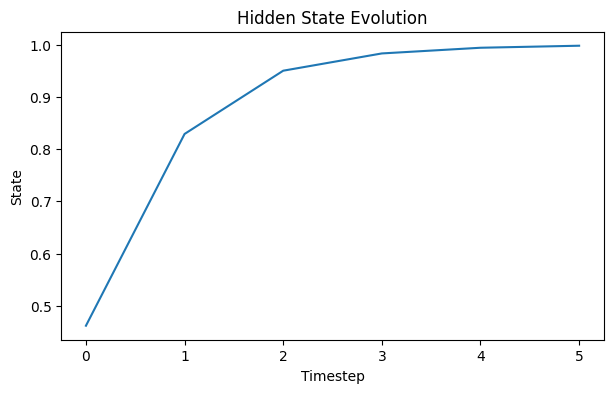

In [8]:

import matplotlib.pyplot as plt

states = simple_rnn_forward(
    [1,2,3,4,5,6],
    0.5,
    0.4
)

plt.figure(figsize=(7,4))
plt.plot(states)
plt.title("Hidden State Evolution")
plt.xlabel("Timestep")
plt.ylabel("State")
plt.show()



# Implementasi Kelas RNN Menggunakan NumPy


In [9]:

class SimpleRNN:

    def __init__(self):

        self.Wx = 0.5
        self.Wh = 0.3
        self.Wy = 0.8

    def forward(self, sequence):

        hidden = 0

        outputs = []

        for x in sequence:

            hidden = np.tanh(
                self.Wx*x +
                self.Wh*hidden
            )

            y = self.Wy*hidden

            outputs.append(y)

        return np.array(outputs)


In [10]:

model = SimpleRNN()

outputs = model.forward([1,2,3,4])

outputs


array([0.36969373, 0.6511632 , 0.75256818, 0.78350643])


# Sequence Prediction

RNN banyak digunakan untuk memprediksi data masa depan.

Contoh:

Input:
1,2,3,4

Target:
5

Model mencoba menangkap pola urutan untuk membuat prediksi.



# Many to One Architecture

Contoh:

Review film → Sentimen

Banyak kata menghasilkan satu output.



# One to Many Architecture

Contoh:

Image Captioning

Satu gambar menghasilkan banyak kata.



# Many to Many Architecture

Contoh:

Machine Translation

Bahasa Inggris → Bahasa Indonesia



# Hubungan dengan LSTM

LSTM dikembangkan untuk mengatasi vanishing gradient.

Komponen utama:

1. Forget Gate
2. Input Gate
3. Output Gate

LSTM dapat menyimpan informasi lebih lama dibandingkan RNN biasa.



# Hubungan dengan GRU

GRU merupakan versi yang lebih sederhana dibandingkan LSTM.

Keunggulan:

1. Parameter lebih sedikit.
2. Training lebih cepat.
3. Performa kompetitif.



# Hubungan dengan Transformer

Walaupun Transformer saat ini mendominasi NLP modern, banyak konsep penting berasal dari penelitian RNN.

Transformer menggantikan mekanisme memori berurutan dengan attention mechanism.



# Kelebihan RNN

1. Cocok untuk data sekuensial.
2. Mendukung panjang input berbeda.
3. Dapat memanfaatkan konteks sebelumnya.
4. Menjadi fondasi banyak model NLP.



# Keterbatasan RNN

1. Vanishing gradient.
2. Sulit menangani dependensi panjang.
3. Training relatif lambat.
4. Sulit diparalelkan.



# Latihan

1. Ubah fungsi aktivasi menjadi ReLU.
2. Tambahkan embedding layer.
3. Implementasikan many to one classifier.
4. Visualisasikan hidden state.
5. Bandingkan RNN dan feedforward network.



# Kesimpulan

Pada chapter ini kita mempelajari:

1. Data sekuensial.
2. Hidden state.
3. Recurrent Neural Network.
4. Weight sharing.
5. Forward propagation.
6. Backpropagation Through Time.
7. Implementasi NumPy dari nol.
8. Sequence modeling.
9. LSTM dan GRU.
10. Hubungan dengan Transformer.

RNN merupakan langkah penting dalam evolusi deep learning karena memungkinkan neural network memahami data yang memiliki urutan dan konteks waktu.
